In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [24]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [25]:
b1= bd.iloc[12]

In [29]:
b1['datetime']

'2019-11-18,13:54:00.503167+00:00'

In [5]:
lat= literal_eval(b1['lat_stereo_g16'])
long= literal_eval(b1['lat_stereo_g16'])
alt= literal_eval(b1['alt_stereo_g16'])
energy = literal_eval(b1['energyJoules_stereo_g16'])

In [6]:
print (np.abs(lat[25]-lat[0]), np.abs(long[25]-long[0]), np.abs(alt[25]-alt[0]))

0.029455450000000383 0.029455450000000383 7.517602240000002


In [21]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [8]:
findtheta(lat, long, alt)

0.013133230608010946

In [9]:
np.cos(findtheta(lat, long, alt))

0.9999137603664726

In [10]:
print (len(lat), len(long), len(alt), len(energy))

59 59 59 59


In [11]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

25


In [19]:
totalmass= 0
totalh= 0 
for i in range (25): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [20]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

3.7363372446515904e-05 1.7436240475040753e-05 0.00017436240475040754


In [14]:
totalh

8893.897051111808

In [15]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

5.711805010000006
-0.0013991800000070498
-0.0009289300000006051
-0.0014011399999986907
0.0009651600000069038
0.0004610900000017182
0.000934979999996699
0.0009273099999944634
0.00045323999999880016
0.0004681400000094982
-0.0009459600000099044
-0.001412939999994478
-0.0014166699999975663
-0.0014149499999973614
-8.140000005596448e-06
0.0018809700000019802
0.0018846899999971356
0.00236194999999384
0.002357570000000919
1.1430000000700602e-05
-0.0014030299999916451
-0.00044852000000616954
-0.00045158999999728167
-0.0009244600000073433
1.805246210000007
-0.6695026000000013
1.3277615899999944
0.6222994400000061
0.1879650799999979
0.6107953399999957
0.6344200900000061
0.9602520800000036
2.021286889999999
3.733296209999992
5.250000000955879e-06
0.0014207000000112657
-0.3121526800000112
-0.031909299999995255
-0.03096999999999639
0.026290930000001822
-0.10141244000000427
0.012655210000005468
-0.03382057000000316
-0.010818710000009446
-0.1276923599999975
-0.10607997999998986
-0.010289210000010485
0

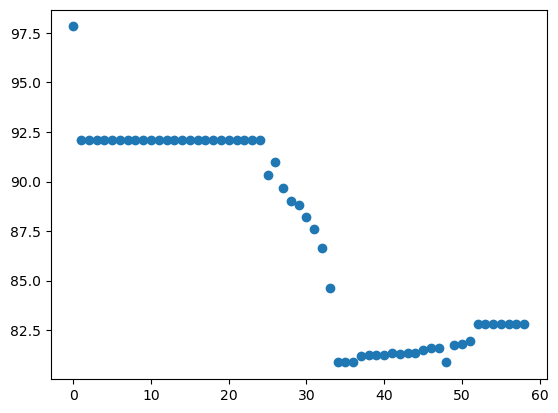

In [17]:
plt.scatter(range(len(alt)), alt)